# 09 - Top-8 subject local/global variability (valid85, all exemplars)

This notebook computes per-subject, per-category local/global variability for the same top-8 subjects used by notebook `04_individual_rdms.ipynb`.

## Subject selection
- Uses notebook 04 convention: top-8 by `density` from `trajectory_correlations.csv`.
- If `density` is missing, uses `n_categories_younger + n_categories_older`.

## Data/filtering
- Restricts to `valid85` categories.
- Uses all `regular` exemplars from the sampled manifest for those categories/subjects.
- Does **not** apply per-file/per-class precision filtering.

## Metrics (per subject, per category)
- `mean_knn_dist`: mean distance to k nearest neighbors within the same category.
- `local_coherence`: `1 / mean_knn_dist`.
- `global_dispersion`: mean distance to that subject-category centroid.
- `local_over_global`: `local_coherence / global_dispersion`.

## Plotting convention in this notebook
- Local variability panels use `mean_knn_dist` (distance space, CCN-consistent), not `local_coherence`.
- Ratio panels still use `local_over_global` (`local_coherence / global_dispersion`).

In [4]:
from __future__ import annotations

from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.neighbors import NearestNeighbors
from tqdm.auto import tqdm

# Paths and constants
SCRIPT_DIR = Path.cwd().resolve()
if SCRIPT_DIR.name != 'preprint-2026':
    SCRIPT_DIR = Path('/home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026')

PROJECT_ROOT = SCRIPT_DIR.parent.parent
ANALYSIS_DIR = PROJECT_ROOT / 'analysis'
PREPRINT_DIR = ANALYSIS_DIR / 'preprint-2026'

CATEGORY_SET = 'valid85'
INCLUDED_CATEGORIES_TXT = PROJECT_ROOT / 'data' / 'included_categories_valid85.txt'
SAMPLED_EXEMPLAR_CSV = PROJECT_ROOT / 'annotation' / 'sampled_object_crops_100_bucket_assignments_100ex_8subj_per_video_cap_babyview_only.csv'
TRAJECTORY_CSV = ANALYSIS_DIR / 'individual_analyses' / 'developmental_trajectory_rdms_clip' / 'trajectory_correlations.csv'

OUTPUT_RUN_ROOT = PREPRINT_DIR / 'supplemental_results_valid85cats_04202026'
RESULTS_DIR = OUTPUT_RUN_ROOT / 'results'
FIGURES_DIR = OUTPUT_RUN_ROOT / 'figures'

OUT_SUBDIR = RESULTS_DIR / 'top8_subject_local_global_variability_valid85_all_regular'
OUT_SUBDIR.mkdir(parents=True, exist_ok=True)

MODEL_CONFIGS = {
    'clip': {
        'embeddings_dir': Path('/data2/dataset/babyview/868_hours/outputs/yoloe_cdi_embeddings/clip_embeddings_new'),
    },
    'dinov3': {
        'embeddings_dir': Path('/data2/dataset/babyview/868_hours/outputs/yoloe_cdi_embeddings/facebook_dinov3-vitb16-pretrain-lvd1689m'),
    },
}

N_TOP_DENSEST = 8
K = 5

# Match notebook 04 optimization/style knobs.
EMBED_LOAD_MAX_WORKERS = max(4, min(16, (os.cpu_count() or 8)))
EMBED_PARALLEL_CATEGORIES = True
EMBED_CATEGORY_MAX_WORKERS = min(8, max(2, (os.cpu_count() or 4) // 2))
MAX_EXEMPLARS_PER_CATEGORY: int | None = 128
EXEMPLAR_SUBSAMPLE_SEED = 42

# Use notebook 04 convention: L2-normalize exemplar vectors before aggregation/metrics.
L2_NORMALIZE_EXEMPLARS = True

print(f'Output directory: {OUT_SUBDIR}')
print(f'Using CATEGORY_SET={CATEGORY_SET}, k={K}')
print(f'EMBED_PARALLEL_CATEGORIES / workers: {EMBED_PARALLEL_CATEGORIES} / {EMBED_CATEGORY_MAX_WORKERS}')
print(f'EMBED_LOAD_MAX_WORKERS: {EMBED_LOAD_MAX_WORKERS}')
print(f'MAX_EXEMPLARS_PER_CATEGORY: {MAX_EXEMPLARS_PER_CATEGORY}')
print(f'L2_NORMALIZE_EXEMPLARS: {L2_NORMALIZE_EXEMPLARS}')

Output directory: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04202026/results/top8_subject_local_global_variability_valid85_all_regular
Using CATEGORY_SET=valid85, k=5


In [5]:
def parse_subject_id_from_stem(stem: str) -> str | None:
    # Match notebook 04 parser: support both YOLOE and legacy subject-first stems.
    parts = stem.split('_')
    if len(parts) >= 6:
        sid = parts[2].strip()
        if sid.isdigit():
            return sid.zfill(8)
    if parts and parts[0].strip().isdigit():
        return parts[0].strip().zfill(8)
    return None


def _stem_quick_maybe_subject(stem: str, allow: set[str]) -> bool:
    for sid in allow:
        if stem.startswith(f'{sid}_') or f'_{sid}_' in stem:
            return True
    return False


def _iter_category_npy_paths(cat_dir: Path, subject_ids_filter: set[str] | None):
    if subject_ids_filter is None:
        yield from cat_dir.glob('*.npy')
        return

    with os.scandir(cat_dir) as it:
        for entry in it:
            if not entry.is_file(follow_symlinks=False):
                continue
            name = entry.name
            if not name.endswith('.npy'):
                continue
            stem = name[:-4]
            if not _stem_quick_maybe_subject(stem, subject_ids_filter):
                continue
            yield Path(entry.path)


def _load_npy_task(item: tuple[Path, str, str]):
    path, subject_id, category = item
    try:
        emb = np.load(path)
    except Exception:
        return None
    return subject_id, category, np.asarray(emb, dtype=np.float64).reshape(-1)


def _l2_normalize_vec(v: np.ndarray) -> np.ndarray:
    x = np.asarray(v, dtype=np.float64).ravel()
    n = np.linalg.norm(x)
    return x / n if n > 0 else x


def get_top8_subjects_from_trajectory(trajectory_csv: Path, n_top: int = 8) -> pd.DataFrame:
    traj_df = pd.read_csv(trajectory_csv)
    traj_df['subject_id'] = traj_df['subject_id'].astype(str).str.zfill(8)

    if 'density' not in traj_df.columns:
        needed = {'n_categories_younger', 'n_categories_older'}
        if needed.issubset(set(traj_df.columns)):
            traj_df['density'] = traj_df['n_categories_younger'] + traj_df['n_categories_older']
        else:
            raise ValueError('trajectory_correlations.csv must have density or younger/older category count columns.')

    ranked_density_df = (
        traj_df[['subject_id', 'density']]
        .drop_duplicates(subset=['subject_id'])
        .sort_values('density', ascending=False)
        .reset_index(drop=True)
    )
    return ranked_density_df.head(n_top).copy()


def load_valid85_regular_pairs(
    included_categories_txt: Path,
    sampled_exemplar_csv: Path,
) -> tuple[set[str], set[tuple[str, str]]]:
    valid85_categories = {
        x.strip().lower()
        for x in included_categories_txt.read_text().splitlines()
        if x.strip()
    }

    sampled = pd.read_csv(sampled_exemplar_csv)
    sampled = sampled[sampled['trial_type'] == 'regular'].copy()
    sampled['category'] = sampled['category'].astype(str).str.strip().str.lower()
    sampled['stem'] = sampled['stem'].astype(str).str.strip().str.lower()

    sampled = sampled[sampled['category'].isin(valid85_categories)].copy()
    valid_pairs = set(zip(sampled['category'], sampled['stem']))
    return valid85_categories, valid_pairs


def _load_vectors_for_one_category(
    cat_dir: Path,
    top_subjects: set[str],
    allowed_pairs: set[tuple[str, str]],
    inner_workers: int,
) -> tuple[str, dict[str, list[np.ndarray]]]:
    category = cat_dir.name.strip().lower()
    sid_to_vecs: dict[str, list[np.ndarray]] = defaultdict(list)
    batch: list[tuple[Path, str, str]] = []

    for emb_file in _iter_category_npy_paths(cat_dir, top_subjects):
        stem = emb_file.stem.lower()
        if (category, stem) not in allowed_pairs:
            continue

        subject_id = parse_subject_id_from_stem(stem)
        if subject_id is None or subject_id not in top_subjects:
            continue
        batch.append((emb_file, subject_id, category))

    if not batch:
        return category, {}

    iw = max(1, inner_workers)
    if iw <= 1 or len(batch) < 12:
        for item in batch:
            r = _load_npy_task(item)
            if r is None:
                continue
            sid, _, emb = r
            sid_to_vecs[sid].append(emb)
    else:
        chunksize = max(1, min(256, len(batch) // (iw * 4)))
        with ThreadPoolExecutor(max_workers=iw) as pool:
            for r in pool.map(_load_npy_task, batch, chunksize=chunksize):
                if r is None:
                    continue
                sid, _, emb = r
                sid_to_vecs[sid].append(emb)

    return category, dict(sid_to_vecs)


def compute_subject_category_metrics(
    embeddings_dir: Path,
    allowed_categories: set[str],
    allowed_pairs: set[tuple[str, str]],
    top_subjects: set[str],
    k: int,
) -> pd.DataFrame:
    rows: list[dict] = []

    category_dirs = sorted(
        [p for p in embeddings_dir.iterdir() if p.is_dir() and p.name.strip().lower() in allowed_categories],
        key=lambda p: p.name.lower(),
    )

    category_subject_vectors: dict[str, dict[str, list[np.ndarray]]] = {}
    if EMBED_PARALLEL_CATEGORIES and len(category_dirs) >= 4 and EMBED_CATEGORY_MAX_WORKERS > 1:
        def _one(cd: Path):
            return _load_vectors_for_one_category(cd, top_subjects, allowed_pairs, 1)

        with ThreadPoolExecutor(max_workers=EMBED_CATEGORY_MAX_WORKERS) as pool:
            futs = {pool.submit(_one, cd): cd for cd in category_dirs}
            for fut in tqdm(as_completed(futs), total=len(category_dirs), desc=f'Loading {embeddings_dir.name}'):
                category, sid_map = fut.result()
                category_subject_vectors[category] = sid_map
    else:
        for cat_dir in tqdm(category_dirs, desc=f'Loading {embeddings_dir.name}'):
            category, sid_map = _load_vectors_for_one_category(
                cat_dir,
                top_subjects,
                allowed_pairs,
                EMBED_LOAD_MAX_WORKERS,
            )
            category_subject_vectors[category] = sid_map

    rng = np.random.default_rng(EXEMPLAR_SUBSAMPLE_SEED)
    for category, by_subject in category_subject_vectors.items():
        for subject_id, emb_list in by_subject.items():
            if not emb_list:
                continue

            kept = emb_list
            if MAX_EXEMPLARS_PER_CATEGORY is not None and len(emb_list) > MAX_EXEMPLARS_PER_CATEGORY:
                pick = rng.choice(len(emb_list), size=MAX_EXEMPLARS_PER_CATEGORY, replace=False)
                kept = [emb_list[i] for i in sorted(pick.tolist())]

            if L2_NORMALIZE_EXEMPLARS:
                X = np.stack([_l2_normalize_vec(v) for v in kept], axis=0)
            else:
                X = np.stack([np.asarray(v, dtype=np.float64).reshape(-1) for v in kept], axis=0)

            n = X.shape[0]
            if n < 2:
                rows.append(
                    {
                        'subject_id': subject_id,
                        'category': category,
                        'n_exemplars': int(n),
                        'k': int(k),
                        'effective_k': np.nan,
                        'mean_knn_dist': np.nan,
                        'local_coherence': np.nan,
                        'global_dispersion': np.nan,
                        'local_over_global': np.nan,
                    }
                )
                continue

            effective_k = min(k, n - 1)
            nn = NearestNeighbors(n_neighbors=effective_k + 1, metric='euclidean')
            nn.fit(X)
            dists, _ = nn.kneighbors(X)
            mean_knn = dists[:, 1:].mean(axis=1)

            centroid = X.mean(axis=0, keepdims=True)
            centroid_dists = np.linalg.norm(X - centroid, axis=1)

            mean_knn_dist = float(np.mean(mean_knn))
            global_dispersion = float(np.mean(centroid_dists))
            local_coherence = float(1.0 / mean_knn_dist) if mean_knn_dist > 0 else np.nan
            local_over_global = float(local_coherence / global_dispersion) if global_dispersion > 0 else np.nan

            rows.append(
                {
                    'subject_id': subject_id,
                    'category': category,
                    'n_exemplars': int(n),
                    'k': int(k),
                    'effective_k': int(effective_k),
                    'mean_knn_dist': mean_knn_dist,
                    'local_coherence': local_coherence,
                    'global_dispersion': global_dispersion,
                    'local_over_global': local_over_global,
                }
            )

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    out['local_rank_within_subject'] = out.groupby('subject_id')['local_coherence'].rank(ascending=False, method='average')
    out['global_rank_within_subject'] = out.groupby('subject_id')['global_dispersion'].rank(ascending=False, method='average')
    out['ratio_rank_within_subject'] = out.groupby('subject_id')['local_over_global'].rank(ascending=False, method='average')
    return out.sort_values(['subject_id', 'local_over_global'], ascending=[True, False]).reset_index(drop=True)

In [6]:
# 1) Get the same top-8 subjects as notebook 04

top8_df = get_top8_subjects_from_trajectory(TRAJECTORY_CSV, n_top=N_TOP_DENSEST)
top8_subjects = top8_df['subject_id'].tolist()
top8_set = set(top8_subjects)

print('Top-8 subjects from trajectory density ranking:')
print(top8_df.to_string(index=False))

# 2) Build valid85 + regular sampled exemplar filter (no precision gating)
valid85_categories, valid_pairs = load_valid85_regular_pairs(
    INCLUDED_CATEGORIES_TXT,
    SAMPLED_EXEMPLAR_CSV,
)
print(f'valid85 categories loaded: {len(valid85_categories)}')
print(f'regular sampled (category, stem) pairs in valid85: {len(valid_pairs)}')

# 3) Compute metrics per model
all_subject_summaries = []
all_category_metrics = []

for model_name, cfg in MODEL_CONFIGS.items():
    print('\n' + '=' * 80)
    print(f'Running model: {model_name}')
    print('=' * 80)

    metrics_df = compute_subject_category_metrics(
        embeddings_dir=cfg['embeddings_dir'],
        allowed_categories=valid85_categories,
        allowed_pairs=valid_pairs,
        top_subjects=top8_set,
        k=K,
    )

    if metrics_df.empty:
        raise RuntimeError(f'No rows computed for model={model_name}. Check input paths and filters.')

    metrics_df['model'] = model_name

    # Keep subject order consistent with notebook-04 top-8 order
    order_map = {sid: i for i, sid in enumerate(top8_subjects)}
    metrics_df['subject_order'] = metrics_df['subject_id'].map(order_map)
    metrics_df = metrics_df.sort_values(['subject_order', 'local_over_global'], ascending=[True, False]).drop(columns=['subject_order'])

    subject_summary = (
        metrics_df.groupby('subject_id', as_index=False)
        .agg(
            model=('model', 'first'),
            n_categories=('category', 'nunique'),
            total_exemplars=('n_exemplars', 'sum'),
            mean_local_coherence=('local_coherence', 'mean'),
            mean_global_dispersion=('global_dispersion', 'mean'),
            mean_local_over_global=('local_over_global', 'mean'),
            median_local_over_global=('local_over_global', 'median'),
            mean_knn_dist=('mean_knn_dist', 'mean'),
        )
    )
    subject_summary['subject_order'] = subject_summary['subject_id'].map(order_map)
    subject_summary = subject_summary.sort_values('subject_order').drop(columns=['subject_order']).reset_index(drop=True)

    out_metrics = OUT_SUBDIR / f'top8_subject_category_local_global_{model_name}_{CATEGORY_SET}_k{K}.csv'
    out_summary = OUT_SUBDIR / f'top8_subject_summary_local_global_{model_name}_{CATEGORY_SET}_k{K}.csv'

    metrics_df.to_csv(out_metrics, index=False)
    subject_summary.to_csv(out_summary, index=False)

    all_category_metrics.append(metrics_df)
    all_subject_summaries.append(subject_summary)

    print(f'Saved category-level metrics: {out_metrics}')
    print(f'Saved subject-level summary: {out_summary}')
    display(subject_summary)

# 4) Save combined outputs
combined_category_df = pd.concat(all_category_metrics, ignore_index=True)
combined_subject_df = pd.concat(all_subject_summaries, ignore_index=True)

combined_category_path = OUT_SUBDIR / f'top8_subject_category_local_global_all_models_{CATEGORY_SET}_k{K}.csv'
combined_subject_path = OUT_SUBDIR / f'top8_subject_summary_local_global_all_models_{CATEGORY_SET}_k{K}.csv'
top8_subjects_path = OUT_SUBDIR / 'top8_subjects_from_trajectory.csv'

combined_category_df.to_csv(combined_category_path, index=False)
combined_subject_df.to_csv(combined_subject_path, index=False)
top8_df.to_csv(top8_subjects_path, index=False)

print('\nSaved combined outputs:')
print(f'  {combined_category_path}')
print(f'  {combined_subject_path}')
print(f'  {top8_subjects_path}')

display(combined_subject_df.sort_values(['model', 'subject_id']).reset_index(drop=True))

Top-8 subjects from trajectory density ranking:
subject_id  density
  00400001      318
  00370002      317
  00320001      316
  00400002      315
  00500001      315
  00510002      313
  00430001      310
  00240001      308
valid85 categories loaded: 85
regular sampled (category, stem) pairs in valid85: 8500

Running model: clip


Loading clip_embeddings_new: 100%|██████████| 85/85 [04:59<00:00,  3.53s/it]

Saved category-level metrics: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04202026/results/top8_subject_local_global_variability_valid85_all_regular/top8_subject_category_local_global_clip_valid85_k5.csv
Saved subject-level summary: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04202026/results/top8_subject_local_global_variability_valid85_all_regular/top8_subject_summary_local_global_clip_valid85_k5.csv


,subject_id,model,n_categories,total_exemplars,mean_local_coherence,mean_global_dispersion,mean_local_over_global,median_local_over_global,mean_knn_dist
0,00400001,clip,84,696,0.160550,4.297881,0.038767,0.034585,6.371052
1,00370002,clip,81,642,0.160744,4.271619,0.038930,0.035974,6.366091
2,00320001,clip,75,521,0.162374,4.155726,0.040602,0.037697,6.262674
3,00400002,clip,79,426,0.150876,4.225507,0.037521,0.033971,6.840621
4,00500001,clip,81,362,0.154385,4.033561,0.040522,0.037371,6.657297
5,00510002,clip,67,419,0.168918,3.987528,0.044638,0.041330,6.109411
6,00430001,clip,70,250,0.162577,3.787681,0.045807,0.040693,6.304777
7,00240001,clip,72,310,0.151724,4.120742,0.038409,0.035532,6.727285



Running model: dinov3


Loading facebook_dinov3-vitb16-pretrain-lvd1689m: 100%|██████████| 85/85 [05:36<00:00,  3.95s/it]

Saved category-level metrics: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04202026/results/top8_subject_local_global_variability_valid85_all_regular/top8_subject_category_local_global_dinov3_valid85_k5.csv
Saved subject-level summary: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04202026/results/top8_subject_local_global_variability_valid85_all_regular/top8_subject_summary_local_global_dinov3_valid85_k5.csv


,subject_id,model,n_categories,total_exemplars,mean_local_coherence,mean_global_dispersion,mean_local_over_global,median_local_over_global,mean_knn_dist
0,00400001,dinov3,84,696,0.064637,10.505916,0.006327,0.006076,15.752704
1,00370002,dinov3,81,642,0.065623,10.310435,0.006531,0.006352,15.564956
2,00320001,dinov3,75,521,0.064440,10.322606,0.006394,0.006197,15.703653
3,00400002,dinov3,79,426,0.062889,9.979571,0.006453,0.006186,16.206388
4,00500001,dinov3,81,362,0.062090,9.917033,0.006535,0.006002,16.392011
5,00510002,dinov3,67,419,0.068093,9.753350,0.007344,0.006485,15.039859
6,00430001,dinov3,70,250,0.063727,9.513599,0.006869,0.006657,15.946199
7,00240001,dinov3,72,310,0.063267,9.840557,0.006638,0.005981,16.130214



Saved combined outputs:
  /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04202026/results/top8_subject_local_global_variability_valid85_all_regular/top8_subject_category_local_global_all_models_valid85_k5.csv
  /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04202026/results/top8_subject_local_global_variability_valid85_all_regular/top8_subject_summary_local_global_all_models_valid85_k5.csv
  /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04202026/results/top8_subject_local_global_variability_valid85_all_regular/top8_subjects_from_trajectory.csv


,subject_id,model,n_categories,total_exemplars,mean_local_coherence,mean_global_dispersion,mean_local_over_global,median_local_over_global,mean_knn_dist
0,00240001,clip,72,310,0.151724,4.120742,0.038409,0.035532,6.727285
1,00320001,clip,75,521,0.162374,4.155726,0.040602,0.037697,6.262674
2,00370002,clip,81,642,0.160744,4.271619,0.038930,0.035974,6.366091
3,00400001,clip,84,696,0.160550,4.297881,0.038767,0.034585,6.371052
4,00400002,clip,79,426,0.150876,4.225507,0.037521,0.033971,6.840621
5,00430001,clip,70,250,0.162577,3.787681,0.045807,0.040693,6.304777
6,00500001,clip,81,362,0.154385,4.033561,0.040522,0.037371,6.657297
7,00510002,clip,67,419,0.168918,3.987528,0.044638,0.041330,6.109411
8,00240001,dinov3,72,310,0.063267,9.840557,0.006638,0.005981,16.130214
9,00320001,dinov3,75,521,0.064440,10.322606,0.006394,0.006197,15.703653


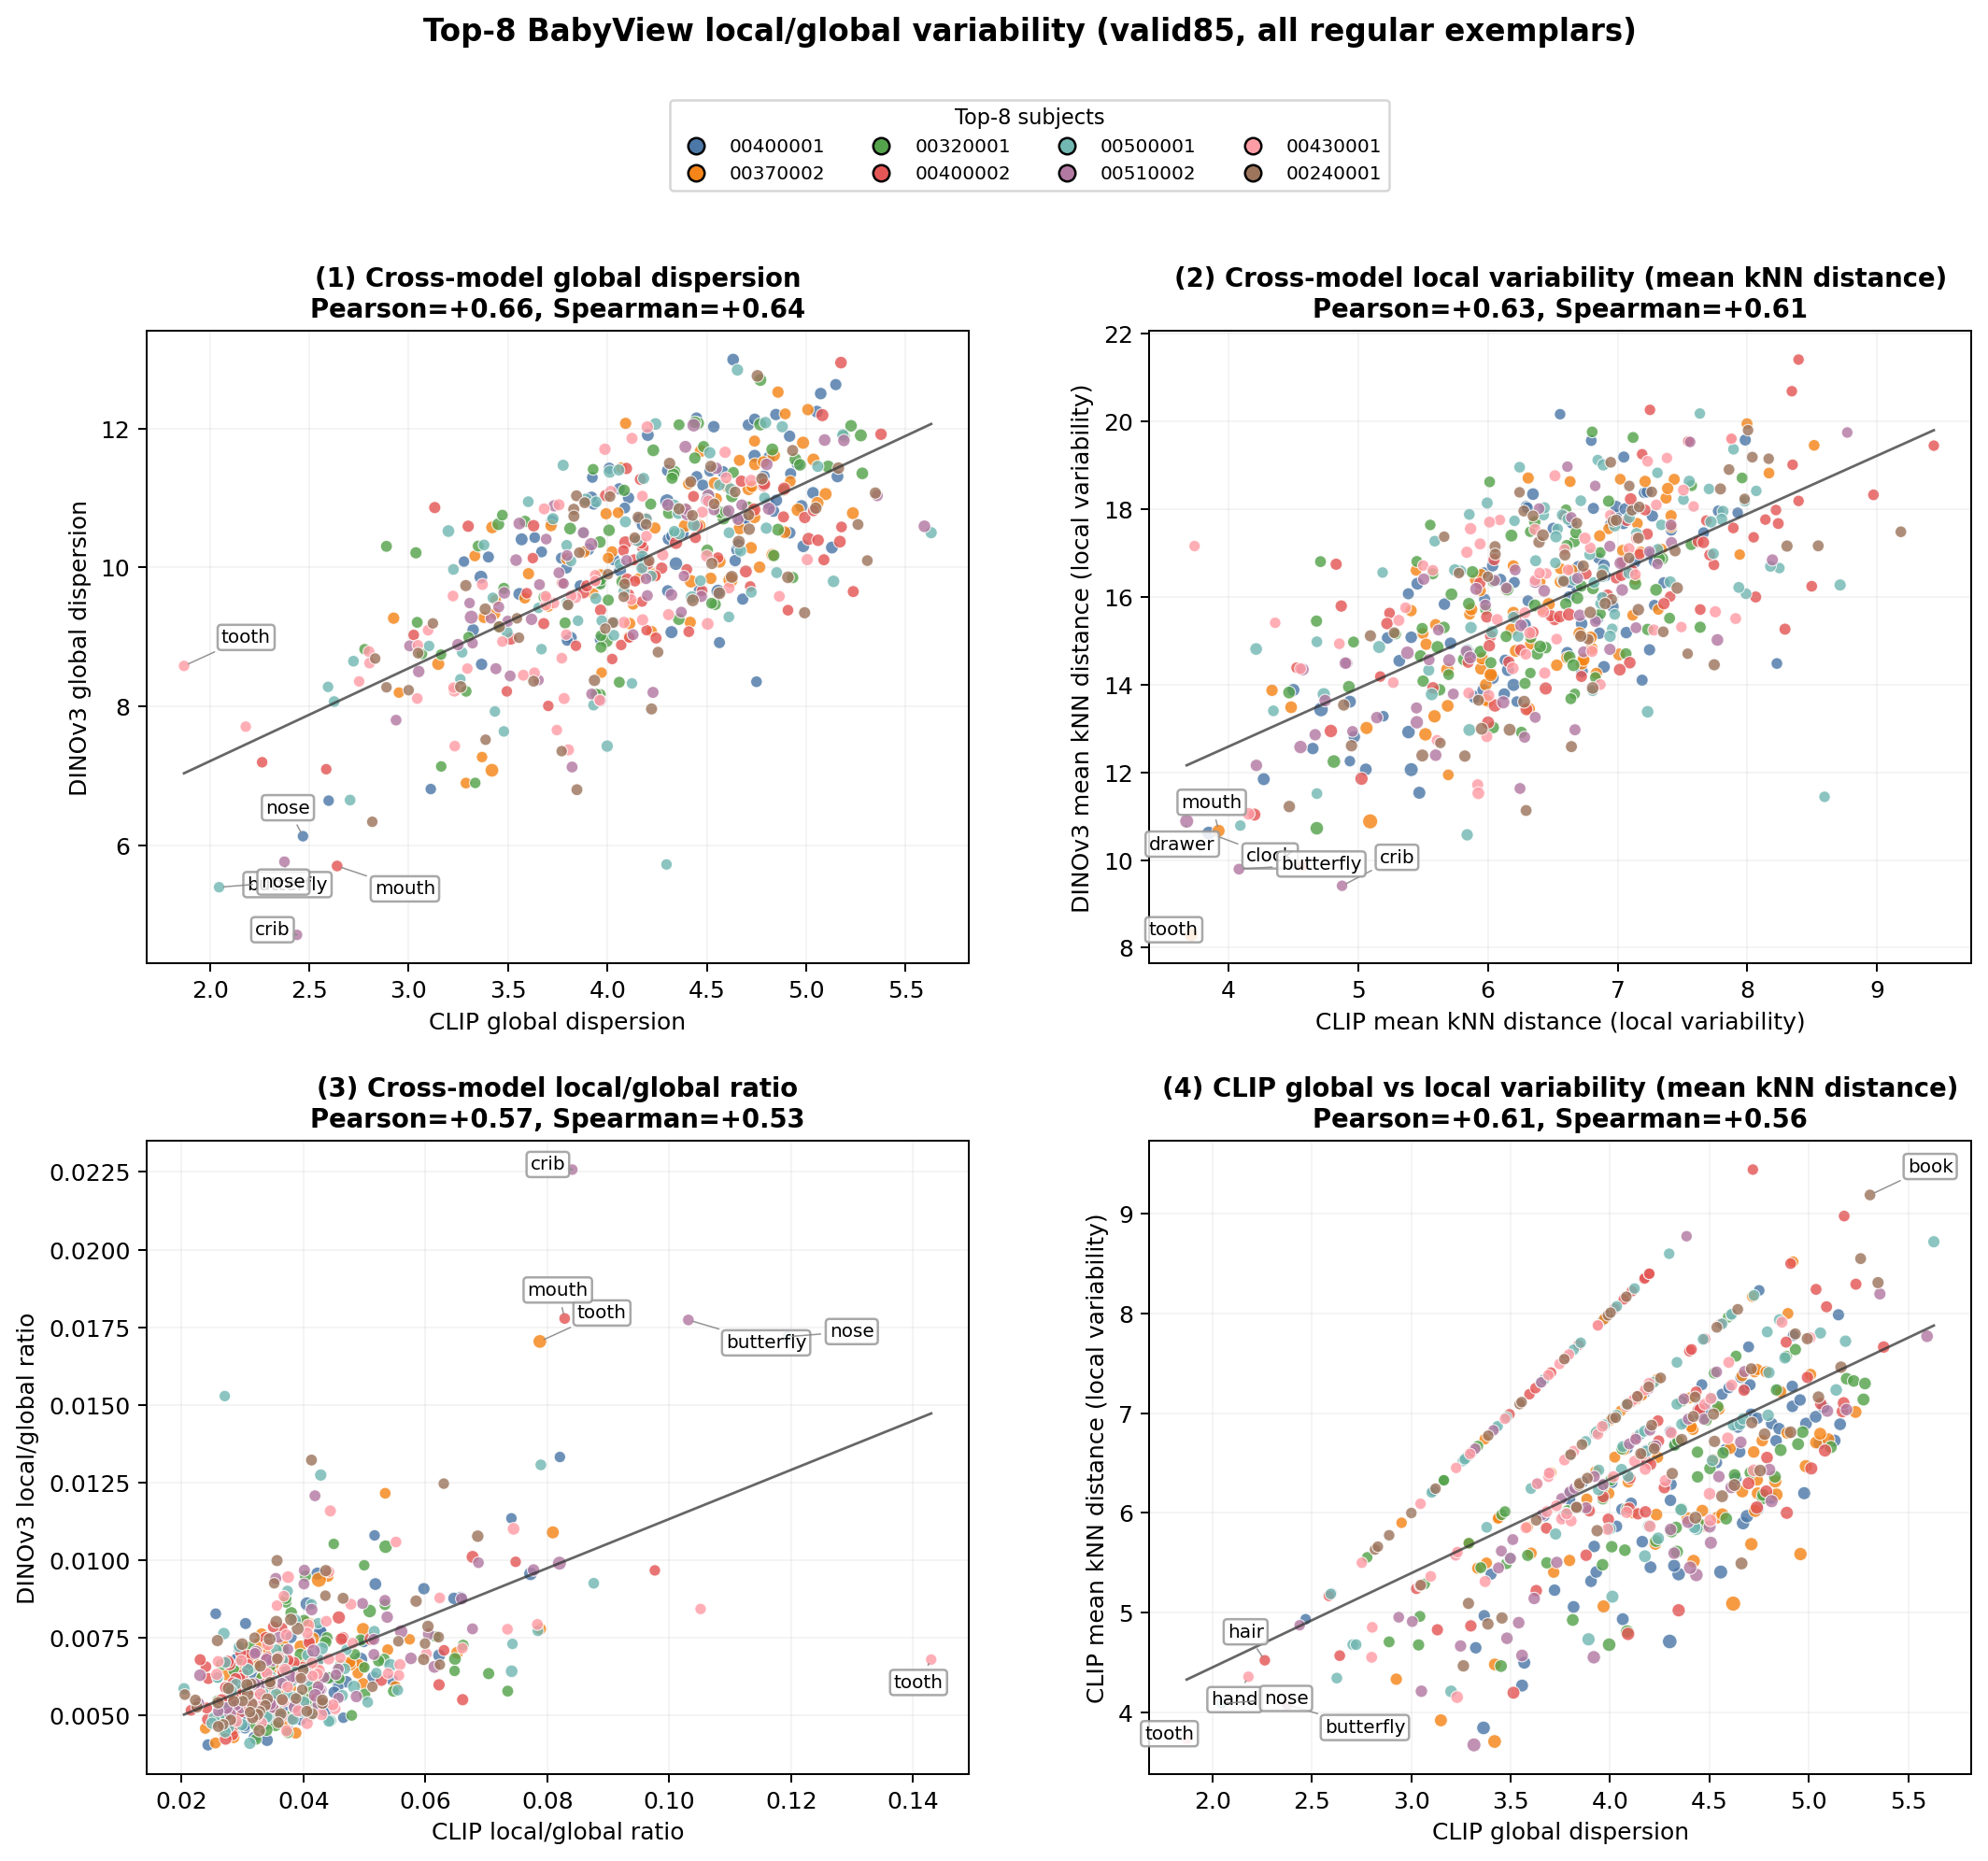

Saved CCN-style 2x2 panel: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04202026/figures/top8_local_global_variability_correlation_2x2_valid85_k5.png
Saved CCN-style 2x2 panel: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04202026/figures/top8_local_global_variability_correlation_2x2_valid85_k5.pdf


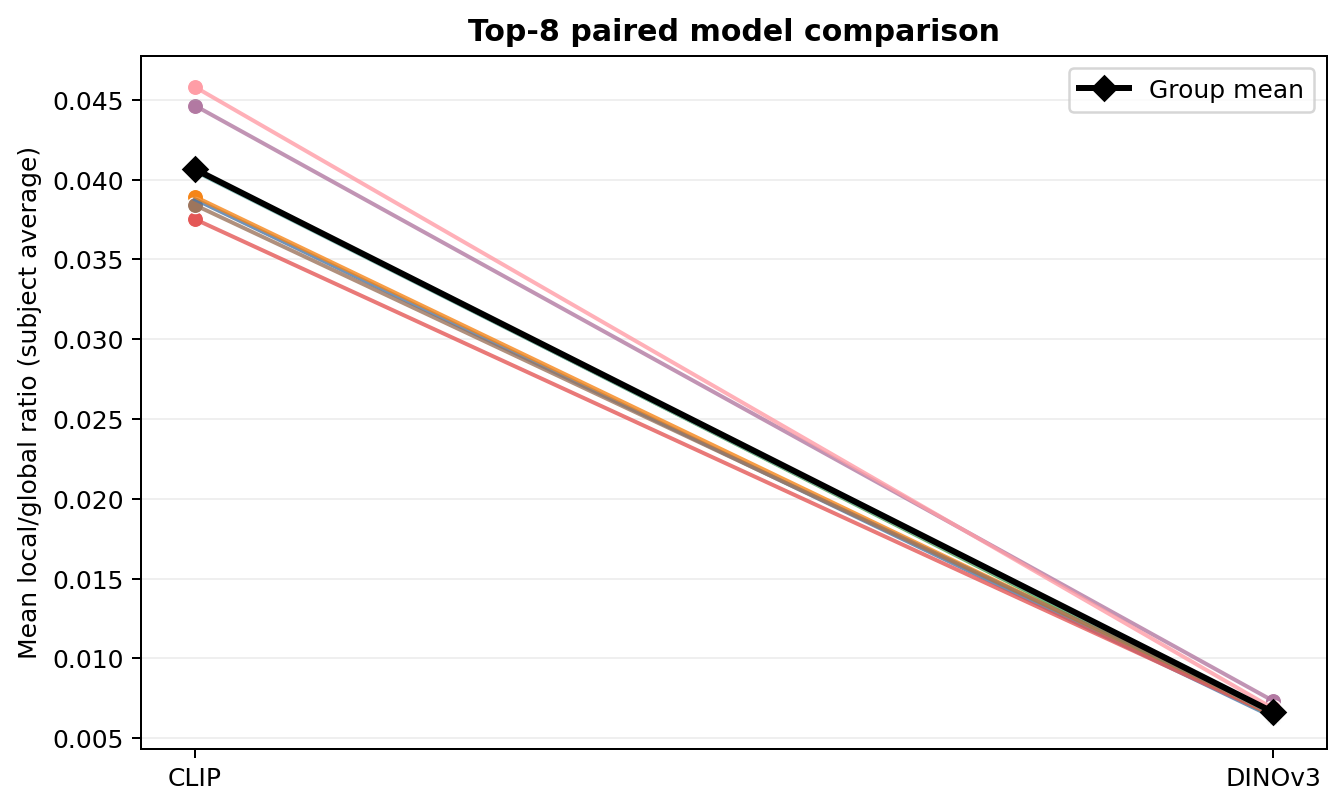

Saved paired subject panel: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04202026/figures/top8_local_over_global_paired_subjects_valid85_k5.png
Saved paired subject panel: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04202026/figures/top8_local_over_global_paired_subjects_valid85_k5.pdf


In [14]:
# 5) CCN-style visualizations

# Keep this cell runnable on a fresh kernel even if setup cells were skipped.
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

if 'combined_category_df' not in globals() or 'combined_subject_df' not in globals():
    combined_category_path = OUT_SUBDIR / f'top8_subject_category_local_global_all_models_{CATEGORY_SET}_k{K}.csv'
    combined_subject_path = OUT_SUBDIR / f'top8_subject_summary_local_global_all_models_{CATEGORY_SET}_k{K}.csv'
    combined_category_df = pd.read_csv(combined_category_path, dtype={'subject_id': str})
    combined_subject_df = pd.read_csv(combined_subject_path, dtype={'subject_id': str})

combined_category_df['subject_id'] = combined_category_df['subject_id'].astype(str).str.zfill(8)
combined_subject_df['subject_id'] = combined_subject_df['subject_id'].astype(str).str.zfill(8)

subject_palette = {
    sid: color for sid, color in zip(
        top8_subjects,
        ['#4C78A8', '#F58518', '#54A24B', '#E45756', '#72B7B2', '#B279A2', '#FF9DA6', '#9D755D'],
    )
}


def _scatter_panel(ax, df, xcol, ycol, title, xlabel, ylabel, n_labels=6):
    x_all = df[xcol].to_numpy(dtype=float)
    y_all = df[ycol].to_numpy(dtype=float)
    sizes_all = 20 + 3.0 * np.sqrt(df['n_exemplars'].clip(lower=1).to_numpy(dtype=float))
    colors_all = df['subject_id'].map(subject_palette).fillna('#999999').tolist()

    finite_mask = np.isfinite(x_all) & np.isfinite(y_all)
    x = x_all[finite_mask]
    y = y_all[finite_mask]
    sizes = sizes_all[finite_mask]
    colors = [c for c, keep in zip(colors_all, finite_mask) if keep]

    ax.scatter(
        x,
        y,
        c=colors,
        s=sizes,
        alpha=0.82,
        edgecolor='white',
        linewidth=0.45,
    )

    stat_txt = 'Pearson=nan, Spearman=nan'
    if len(x) > 2 and np.nanstd(x) > 0 and np.nanstd(y) > 0:
        p = pearsonr(x, y).statistic
        s = spearmanr(x, y).statistic
        stat_txt = f'Pearson={p:+.2f}, Spearman={s:+.2f}'
        try:
            m, b = np.polyfit(x, y, 1)
            xs = np.linspace(np.nanmin(x), np.nanmax(x), 200)
            ys = m * xs + b
            if np.all(np.isfinite(ys)):
                ax.plot(xs, ys, color='#333333', linewidth=1.1, alpha=0.75)
        except Exception:
            # Skip regression line if least-squares is numerically unstable.
            pass
    ax.set_title(f'{title}\n{stat_txt}', fontsize=11, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.18, linewidth=0.6)

    # Label outliers by robust z-score distance in 2D.
    if len(x) > 0:
        zx = (x - np.nanmean(x)) / (np.nanstd(x) + 1e-9)
        zy = (y - np.nanmean(y)) / (np.nanstd(y) + 1e-9)
        score = zx ** 2 + zy ** 2
        idx = np.argsort(score)[-min(n_labels, len(score)):]

        plot_df = df.loc[finite_mask].reset_index(drop=True)
        offsets = [(16, 10), (-16, 10), (16, -12), (-16, -12), (18, 0), (-18, 0)]
        for j, i in enumerate(idx):
            row = plot_df.iloc[int(i)]
            dx, dy = offsets[j % len(offsets)]
            ax.annotate(
                str(row['category']),
                (x[int(i)], y[int(i)]),
                xytext=(dx, dy),
                textcoords='offset points',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='#999999', alpha=0.85),
                arrowprops=dict(arrowstyle='-', color='#888888', lw=0.6, alpha=0.9),
            )


clip_df = combined_category_df[combined_category_df['model'] == 'clip'].copy()
dino_df = combined_category_df[combined_category_df['model'] == 'dinov3'].copy()

corr_df = clip_df[[
    'subject_id', 'category', 'n_exemplars', 'global_dispersion', 'mean_knn_dist', 'local_over_global'
]].rename(columns={
    'global_dispersion': 'global_clip',
    'mean_knn_dist': 'knn_clip',
    'local_over_global': 'ratio_clip',
}).merge(
    dino_df[['subject_id', 'category', 'n_exemplars', 'global_dispersion', 'mean_knn_dist', 'local_over_global']].rename(columns={
        'global_dispersion': 'global_dino',
        'mean_knn_dist': 'knn_dino',
        'local_over_global': 'ratio_dino',
        'n_exemplars': 'n_exemplars_dino',
    }),
    on=['subject_id', 'category'],
    how='inner',
)
corr_df['n_exemplars'] = corr_df[['n_exemplars', 'n_exemplars_dino']].mean(axis=1)

# Plot convention: local variability is mean kNN distance (not inverse coherence).
fig, axes = plt.subplots(2, 2, figsize=(14, 11), dpi=180)
_scatter_panel(
    axes[0, 0],
    corr_df,
    'global_clip',
    'global_dino',
    '(1) Cross-model global dispersion',
    'CLIP global dispersion',
    'DINOv3 global dispersion',
)
_scatter_panel(
    axes[0, 1],
    corr_df,
    'knn_clip',
    'knn_dino',
    '(2) Cross-model local variability (mean kNN distance)',
    'CLIP mean kNN distance (local variability)',
    'DINOv3 mean kNN distance (local variability)',
)
_scatter_panel(
    axes[1, 0],
    corr_df,
    'ratio_clip',
    'ratio_dino',
    '(3) Cross-model local/global ratio',
    'CLIP local/global ratio',
    'DINOv3 local/global ratio',
)
_scatter_panel(
    axes[1, 1],
    corr_df,
    'global_clip',
    'knn_clip',
    '(4) CLIP global vs local variability (mean kNN distance)',
    'CLIP global dispersion',
    'CLIP mean kNN distance (local variability)',
)

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='none', markerfacecolor=subject_palette[s], label=s, markersize=7)
    for s in top8_subjects
]
fig.legend(
    handles=legend_handles,
    title='Top-8 subjects',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    frameon=True,
    fontsize=8,
    title_fontsize=9,
)

fig.suptitle('Top-8 BabyView local/global variability (valid85, all regular exemplars)', y=1.06, fontsize=13, fontweight='bold')
fig.subplots_adjust(top=0.89, hspace=0.28, wspace=0.22)

out_png = FIGURES_DIR / f'top8_local_global_variability_correlation_2x2_{CATEGORY_SET}_k{K}.png'
out_pdf = FIGURES_DIR / f'top8_local_global_variability_correlation_2x2_{CATEGORY_SET}_k{K}.pdf'
fig.savefig(out_png, dpi=300, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f'Saved CCN-style 2x2 panel: {out_png}')
print(f'Saved CCN-style 2x2 panel: {out_pdf}')

# Paired subject plot (CLIP vs DINOv3), similar spirit to CCN paired-delta figure.
subj_plot_df = combined_subject_df.pivot(index='subject_id', columns='model', values='mean_local_over_global').reset_index()
subj_plot_df = subj_plot_df[subj_plot_df['subject_id'].isin(top8_subjects)].copy()
subj_plot_df['subject_order'] = subj_plot_df['subject_id'].map({s: i for i, s in enumerate(top8_subjects)})
subj_plot_df = subj_plot_df.sort_values('subject_order').drop(columns='subject_order')

fig, ax = plt.subplots(figsize=(8.5, 5.0), dpi=180)
for r in subj_plot_df.itertuples(index=False):
    sid = str(r.subject_id)
    ax.plot([0, 1], [float(r.clip), float(r.dinov3)], color=subject_palette.get(sid, '#999999'), alpha=0.8, linewidth=1.6)
    ax.scatter([0, 1], [float(r.clip), float(r.dinov3)], color=subject_palette.get(sid, '#999999'), s=42, edgecolor='white', linewidth=0.5)

clip_mean = float(subj_plot_df['clip'].mean())
dino_mean = float(subj_plot_df['dinov3'].mean())
ax.plot([0, 1], [clip_mean, dino_mean], color='black', linewidth=2.4, marker='D', markersize=7, label='Group mean')

ax.set_xticks([0, 1])
ax.set_xticklabels(['CLIP', 'DINOv3'])
ax.set_ylabel('Mean local/global ratio (subject average)')
ax.set_title('Top-8 paired model comparison', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.2)
ax.legend(loc='best', frameon=True)

out_png2 = FIGURES_DIR / f'top8_local_over_global_paired_subjects_{CATEGORY_SET}_k{K}.png'
out_pdf2 = FIGURES_DIR / f'top8_local_over_global_paired_subjects_{CATEGORY_SET}_k{K}.pdf'
fig.savefig(out_png2, dpi=300, bbox_inches='tight')
fig.savefig(out_pdf2, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f'Saved paired subject panel: {out_png2}')
print(f'Saved paired subject panel: {out_pdf2}')

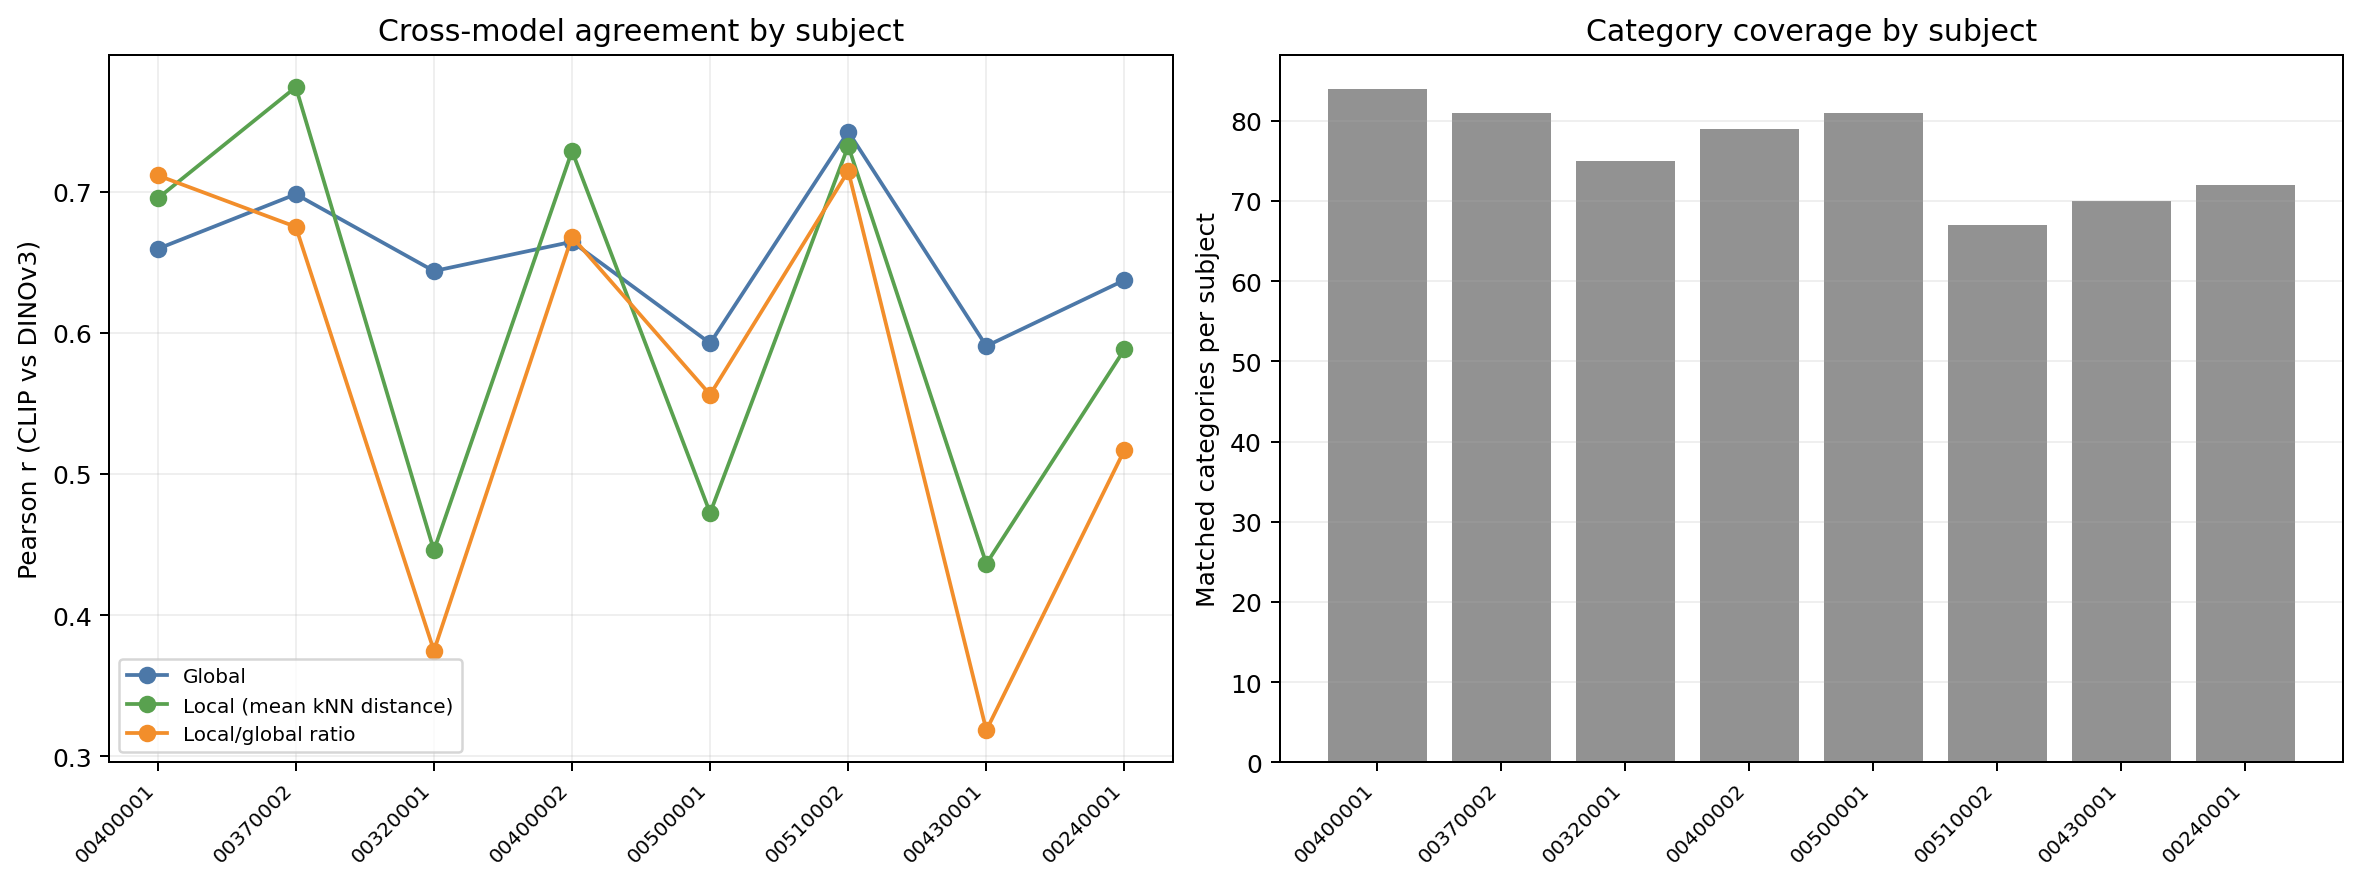

Saved per-subject 2x2 panels in: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04202026/figures/top8_subject_variability_2x2_panels_valid85_k5
Saved subject-level cross-model correlations CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04202026/results/top8_subject_local_global_variability_valid85_all_regular/top8_subject_cross_model_correlations_valid85_k5.csv
Saved cross-subject comparison panel: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04202026/figures/top8_subject_cross_model_comparison_valid85_k5.png
Saved cross-subject comparison panel: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04202026/figures/top8_subject_cross_model_comparison_valid85_k5.pdf


,subject_id,n_categories,pearson_global_clip_vs_dino,pearson_knn_clip_vs_dino,pearson_ratio_clip_vs_dino
0,00400001,84,0.659510,0.695305,0.711599
1,00370002,81,0.698235,0.774125,0.675129
2,00320001,75,0.643786,0.445824,0.374709
3,00400002,79,0.664549,0.728867,0.668018
4,00500001,81,0.592630,0.472332,0.556163
5,00510002,67,0.742603,0.732431,0.714656
6,00430001,70,0.590615,0.436332,0.318332
7,00240001,72,0.637360,0.588239,0.516934


In [15]:
# 6) Per-subject 2x2 panels + cross-subject comparison

if 'corr_df' not in globals():
    combined_category_path = OUT_SUBDIR / f'top8_subject_category_local_global_all_models_{CATEGORY_SET}_k{K}.csv'
    combined_category_df = pd.read_csv(combined_category_path, dtype={'subject_id': str})
    combined_category_df['subject_id'] = combined_category_df['subject_id'].astype(str).str.zfill(8)

    clip_df = combined_category_df[combined_category_df['model'] == 'clip'].copy()
    dino_df = combined_category_df[combined_category_df['model'] == 'dinov3'].copy()

corr_df = clip_df[[
    'subject_id', 'category', 'n_exemplars', 'global_dispersion', 'mean_knn_dist', 'local_over_global'
]].rename(columns={
    'global_dispersion': 'global_clip',
    'mean_knn_dist': 'knn_clip',
    'local_over_global': 'ratio_clip',
}).merge(
    dino_df[['subject_id', 'category', 'n_exemplars', 'global_dispersion', 'mean_knn_dist', 'local_over_global']].rename(columns={
        'global_dispersion': 'global_dino',
        'mean_knn_dist': 'knn_dino',
        'local_over_global': 'ratio_dino',
        'n_exemplars': 'n_exemplars_dino',
    }),
    on=['subject_id', 'category'],
    how='inner',
)
corr_df['n_exemplars'] = corr_df[['n_exemplars', 'n_exemplars_dino']].mean(axis=1)

# Attach CDI semantic labels + CCN-style colors.
semantic_csv = PROJECT_ROOT / 'data' / f'long_tailed_dist_prop_included_categories_{CATEGORY_SET}.csv'
if semantic_csv.exists():
    semantic_df = pd.read_csv(semantic_csv, usecols=['category', 'cdi_semantic']).dropna(subset=['category'])
    semantic_df['category'] = semantic_df['category'].astype(str).str.strip().str.lower()
    semantic_df['cdi_semantic'] = semantic_df['cdi_semantic'].astype(str).str.strip()
else:
    semantic_df = pd.DataFrame(columns=['category', 'cdi_semantic'])

CDI_SEMANTIC_COLORS = {
    'animals': '#4DB8A8',
    'body_parts': '#E87A5F',
    'clothing': '#9B7EC8',
    'food_drink': '#E8A54C',
    'furniture_rooms': '#6BAB7A',
    'household': '#D97B9E',
    'outside': '#5B9BD5',
    'people': '#E8C44C',
    'toys': '#B07CC8',
    'vehicles': '#6BA3D5',
    'other': '#8B9A9E',
}

corr_df['category'] = corr_df['category'].astype(str).str.strip().str.lower()
corr_df = corr_df.merge(semantic_df, on='category', how='left')
corr_df['cdi_semantic'] = corr_df['cdi_semantic'].fillna('other')
corr_df['dot_color'] = corr_df['cdi_semantic'].map(lambda s: CDI_SEMANTIC_COLORS.get(s, CDI_SEMANTIC_COLORS['other']))

# Plot convention: local variability is mean kNN distance (not inverse coherence).

def _safe_corr(x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) < 3 or np.nanstd(x) <= 0 or np.nanstd(y) <= 0:
        return float('nan'), float('nan')
    return float(pearsonr(x, y).statistic), float(spearmanr(x, y).statistic)


def _panel_subject(ax, df, xcol, ycol, title, xlabel, ylabel):
    x = df[xcol].to_numpy(dtype=float)
    y = df[ycol].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    plot_df = df.loc[mask].copy()
    n_vals = plot_df['n_exemplars'].clip(lower=1).to_numpy(dtype=float)
    nmin = float(np.nanmin(n_vals)) if len(n_vals) else 1.0
    nmax = float(np.nanmax(n_vals)) if len(n_vals) else 1.0
    if np.isclose(nmin, nmax):
        sizes = np.full(len(plot_df), 70.0)
    else:
        sizes = 40.0 + (n_vals - nmin) / (nmax - nmin) * 220.0

    ax.scatter(
        x,
        y,
        s=sizes,
        c=plot_df['dot_color'].tolist(),
        alpha=0.82,
        edgecolor='white',
        linewidth=0.5,
    )

    pr, sr = _safe_corr(x, y)
    if np.isfinite(pr):
        try:
            m, b = np.polyfit(x, y, 1)
            xs = np.linspace(np.nanmin(x), np.nanmax(x), 150)
            ys = m * xs + b
            if np.all(np.isfinite(ys)):
                ax.plot(xs, ys, color='#333333', linewidth=1.0, alpha=0.75)
        except Exception:
            pass

    ax.set_title(f"{title}\nPearson={pr:+.2f}, Spearman={sr:+.2f}", fontsize=10, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.18, linewidth=0.6)


subject_corr_rows = []
per_subject_dir = FIGURES_DIR / f'top8_subject_variability_2x2_panels_{CATEGORY_SET}_k{K}'
per_subject_dir.mkdir(parents=True, exist_ok=True)

for sid in top8_subjects:
    sdf = corr_df[corr_df['subject_id'] == sid].copy()
    if sdf.empty:
        continue

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), dpi=180)
    _panel_subject(
        axes[0, 0], sdf, 'global_clip', 'global_dino',
        '(1) Cross-model global dispersion', 'CLIP global dispersion', 'DINOv3 global dispersion'
    )
    _panel_subject(
        axes[0, 1], sdf, 'knn_clip', 'knn_dino',
        '(2) Cross-model local variability (mean kNN distance)', 'CLIP mean kNN distance', 'DINOv3 mean kNN distance'
    )
    _panel_subject(
        axes[1, 0], sdf, 'ratio_clip', 'ratio_dino',
        '(3) Cross-model local/global ratio', 'CLIP local/global ratio', 'DINOv3 local/global ratio'
    )
    _panel_subject(
        axes[1, 1], sdf, 'global_clip', 'knn_clip',
        '(4) CLIP global vs local variability (mean kNN distance)', 'CLIP global dispersion', 'CLIP mean kNN distance'
    )

    n_cat = int(sdf['category'].nunique())
    fig.suptitle(f'Subject {sid}: local/global variability ({n_cat} categories)', fontsize=13, fontweight='bold', y=1.02)

    semantic_present = [s for s in CDI_SEMANTIC_COLORS.keys() if s in set(sdf['cdi_semantic'])]
    semantic_handles = [
        plt.Line2D(
            [0],
            [0],
            marker='o',
            color='none',
            markerfacecolor=CDI_SEMANTIC_COLORS[s],
            markeredgecolor='none',
            markersize=7,
            label=s,
        )
        for s in semantic_present
    ]
    if semantic_handles:
        fig.legend(
            handles=semantic_handles,
            loc='upper center',
            bbox_to_anchor=(0.5, 0.985),
            ncol=min(6, len(semantic_handles)),
            frameon=True,
            title='CDI semantic',
            prop={'size': 8},
            title_fontsize=9,
        )

    n_vals = sdf['n_exemplars'].to_numpy(dtype=float)
    q_vals = np.unique(np.round(np.quantile(n_vals, [0.25, 0.5, 0.75])).astype(int)).tolist()
    if len(q_vals) > 0:
        nmin = float(np.nanmin(n_vals))
        nmax = float(np.nanmax(n_vals))
        size_handles = []
        for q in q_vals:
            if np.isclose(nmin, nmax):
                s = 70.0
            else:
                s = 40.0 + (float(q) - nmin) / (nmax - nmin) * 220.0
            size_handles.append(
                plt.Line2D(
                    [0],
                    [0],
                    marker='o',
                    color='none',
                    markerfacecolor='#777777',
                    markeredgecolor='none',
                    markersize=max(4.0, np.sqrt(s)),
                    label=f'n={int(q)}',
                )
            )
        fig.legend(
            handles=size_handles,
            loc='lower center',
            bbox_to_anchor=(0.5, 0.01),
            ncol=len(size_handles),
            frameon=True,
            title='Exemplar count',
            prop={'size': 8},
            title_fontsize=9,
        )

    fig.subplots_adjust(top=0.86, bottom=0.11, hspace=0.28, wspace=0.24)

    out_png = per_subject_dir / f'subject_{sid}_variability_correlation_2x2_{CATEGORY_SET}_k{K}.png'
    out_pdf = per_subject_dir / f'subject_{sid}_variability_correlation_2x2_{CATEGORY_SET}_k{K}.pdf'
    fig.savefig(out_png, dpi=300, bbox_inches='tight')
    fig.savefig(out_pdf, bbox_inches='tight')
    plt.close(fig)

    pr_g, _ = _safe_corr(sdf['global_clip'].to_numpy(dtype=float), sdf['global_dino'].to_numpy(dtype=float))
    pr_l, _ = _safe_corr(sdf['knn_clip'].to_numpy(dtype=float), sdf['knn_dino'].to_numpy(dtype=float))
    pr_r, _ = _safe_corr(sdf['ratio_clip'].to_numpy(dtype=float), sdf['ratio_dino'].to_numpy(dtype=float))
    subject_corr_rows.append({
        'subject_id': sid,
        'n_categories': n_cat,
        'pearson_global_clip_vs_dino': pr_g,
        'pearson_knn_clip_vs_dino': pr_l,
        'pearson_ratio_clip_vs_dino': pr_r,
    })

subject_corr_df = pd.DataFrame(subject_corr_rows)
subject_corr_df['subject_order'] = subject_corr_df['subject_id'].map({s: i for i, s in enumerate(top8_subjects)})
subject_corr_df = subject_corr_df.sort_values('subject_order').drop(columns='subject_order').reset_index(drop=True)

corr_csv = OUT_SUBDIR / f'top8_subject_cross_model_correlations_{CATEGORY_SET}_k{K}.csv'
subject_corr_df.to_csv(corr_csv, index=False)

# Cross-subject comparison figure
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), dpi=180, constrained_layout=True)
x = np.arange(len(subject_corr_df))
labels = subject_corr_df['subject_id'].tolist()

axes[0].plot(x, subject_corr_df['pearson_global_clip_vs_dino'], marker='o', color='#4C78A8', label='Global')
axes[0].plot(x, subject_corr_df['pearson_knn_clip_vs_dino'], marker='o', color='#59A14F', label='Local (mean kNN distance)')
axes[0].plot(x, subject_corr_df['pearson_ratio_clip_vs_dino'], marker='o', color='#F28E2B', label='Local/global ratio')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Pearson r (CLIP vs DINOv3)')
axes[0].set_title('Cross-model agreement by subject')
axes[0].grid(alpha=0.2)
axes[0].legend(frameon=True, fontsize=8)

axes[1].bar(x, subject_corr_df['n_categories'], color='#7F7F7F', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Matched categories per subject')
axes[1].set_title('Category coverage by subject')
axes[1].grid(axis='y', alpha=0.2)

out_cmp_png = FIGURES_DIR / f'top8_subject_cross_model_comparison_{CATEGORY_SET}_k{K}.png'
out_cmp_pdf = FIGURES_DIR / f'top8_subject_cross_model_comparison_{CATEGORY_SET}_k{K}.pdf'
fig.savefig(out_cmp_png, dpi=300, bbox_inches='tight')
fig.savefig(out_cmp_pdf, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f'Saved per-subject 2x2 panels in: {per_subject_dir}')
print(f'Saved subject-level cross-model correlations CSV: {corr_csv}')
print(f'Saved cross-subject comparison panel: {out_cmp_png}')
print(f'Saved cross-subject comparison panel: {out_cmp_pdf}')
display(subject_corr_df)

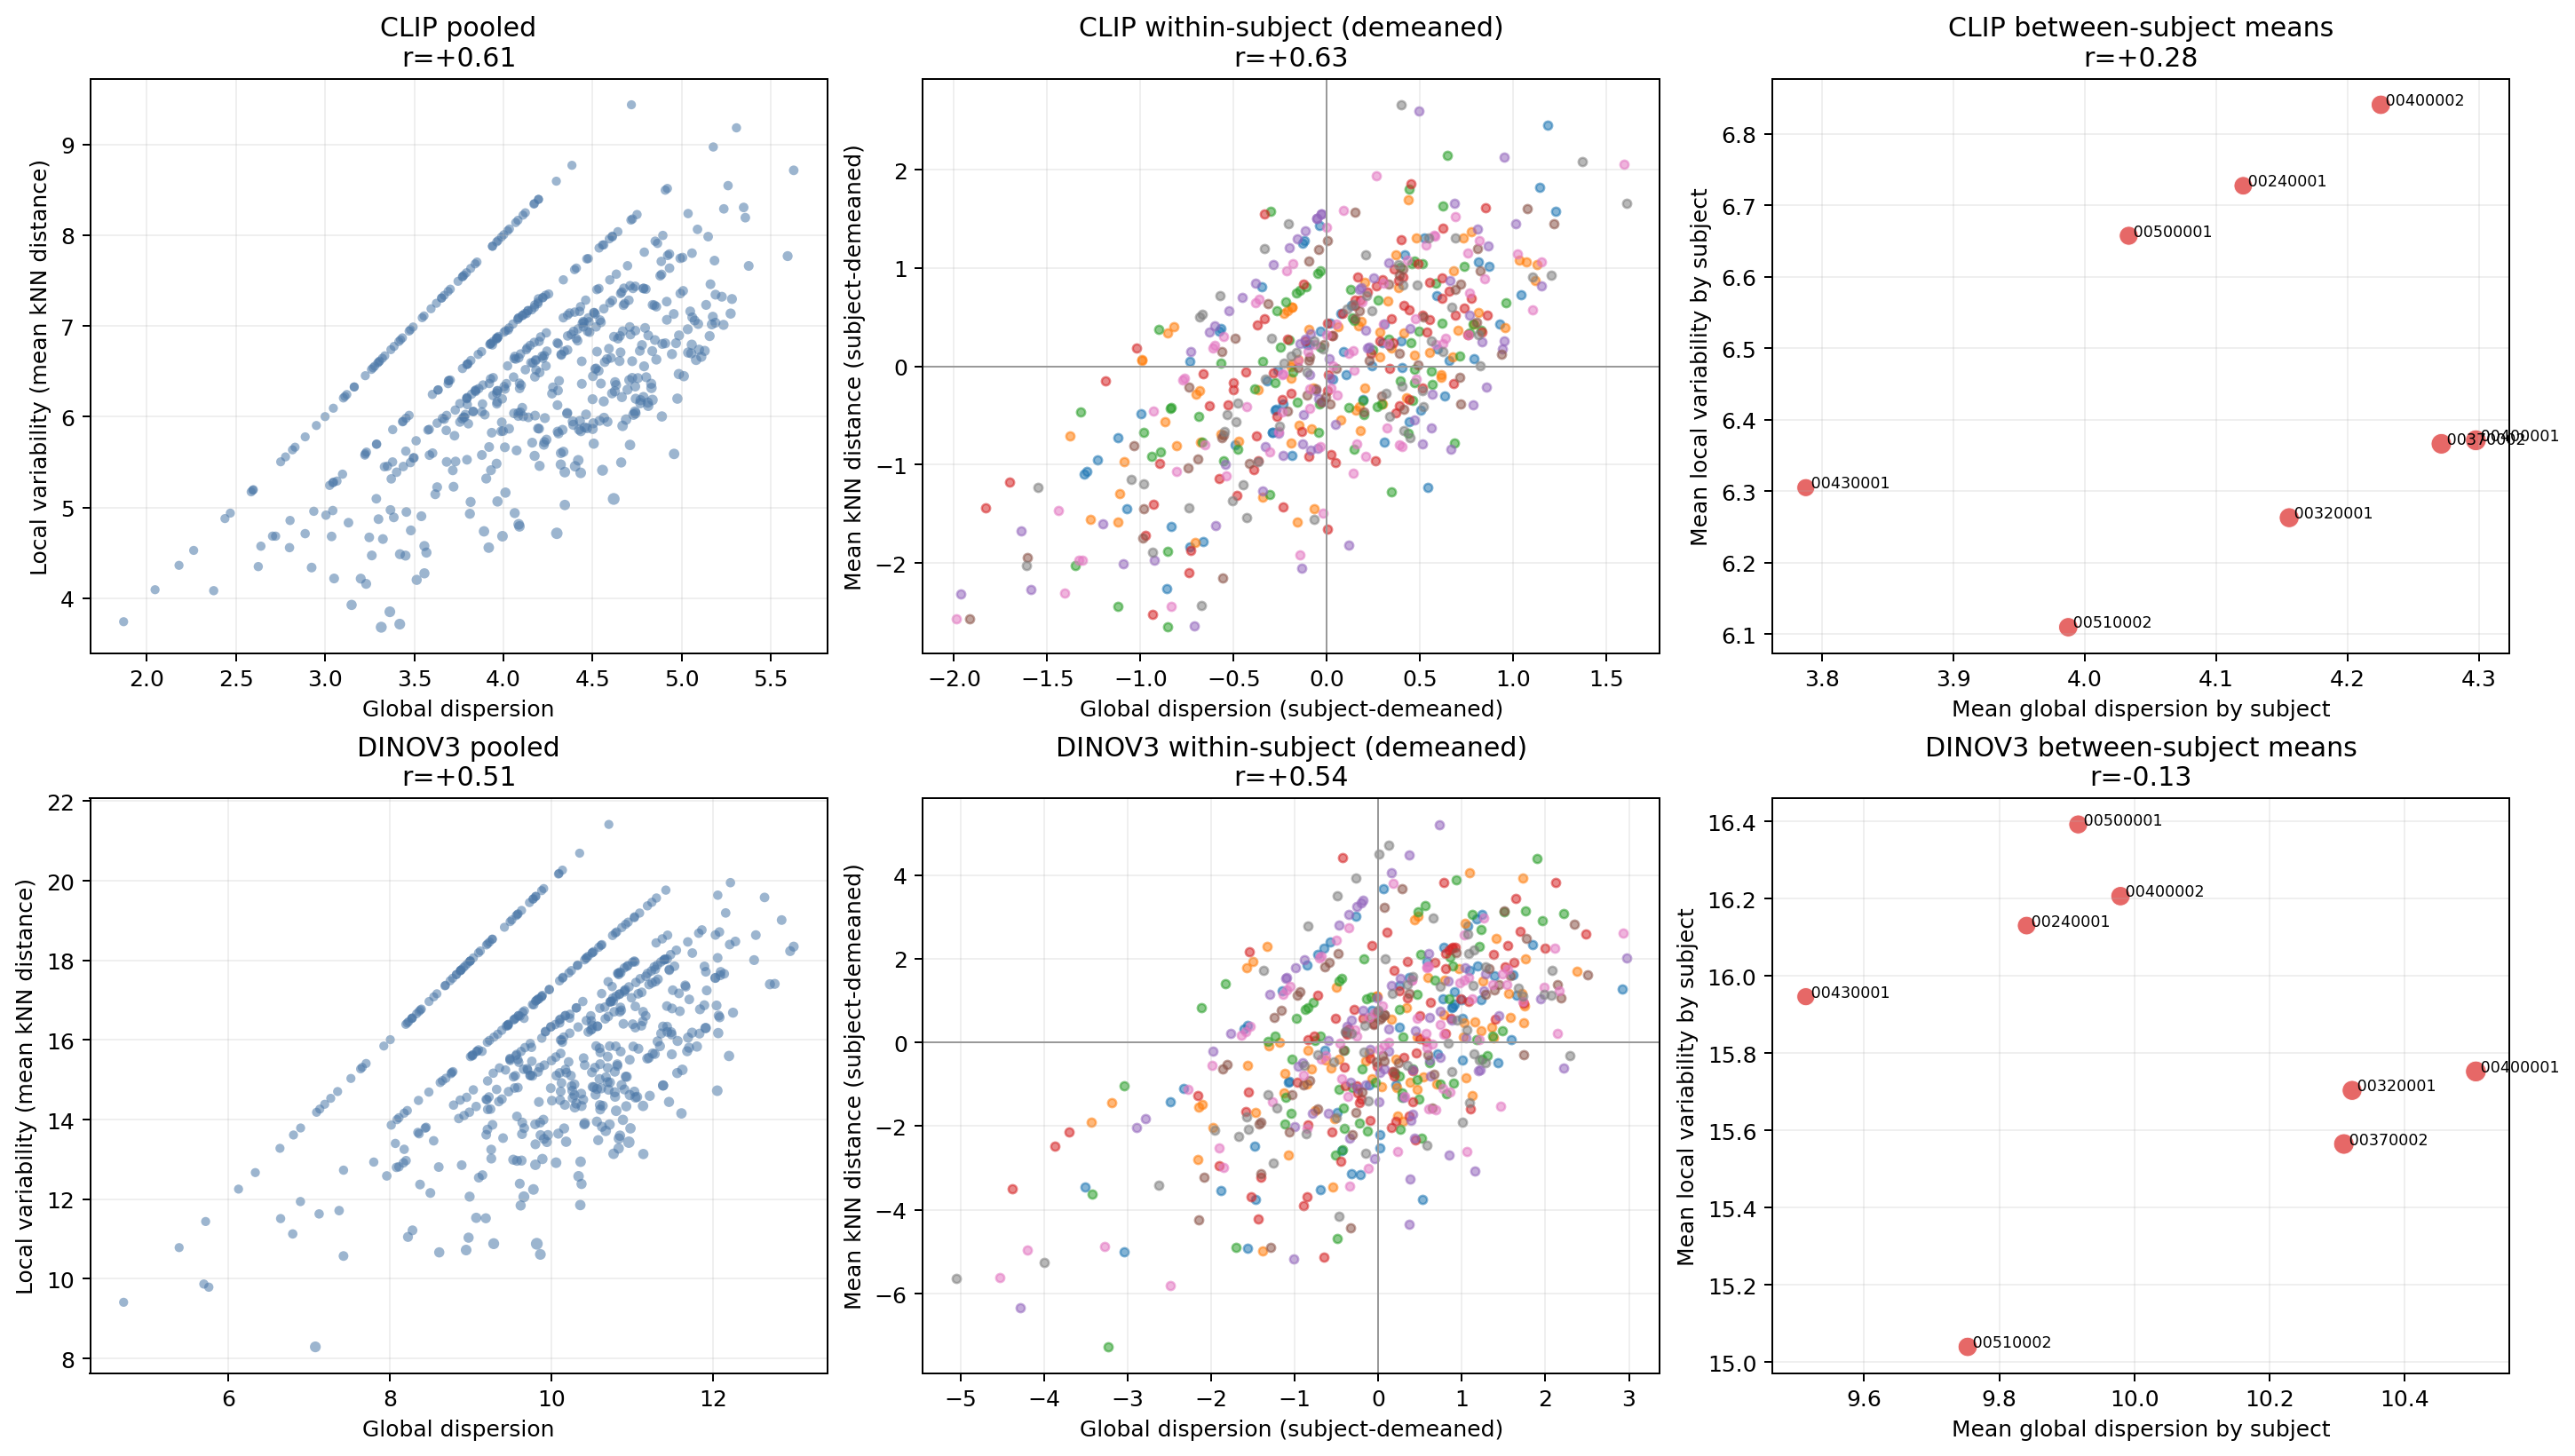

Saved within/between diagnostic: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04202026/figures/top8_local_global_within_between_diagnostic_valid85_k5.png
Saved within/between diagnostic: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04202026/figures/top8_local_global_within_between_diagnostic_valid85_k5.pdf


In [16]:
# 7) Diagnostic: pooled vs within-subject vs between-subject correlations

if 'corr_df' not in globals():
    combined_category_path = OUT_SUBDIR / f'top8_subject_category_local_global_all_models_{CATEGORY_SET}_k{K}.csv'
    combined_category_df = pd.read_csv(combined_category_path, dtype={'subject_id': str})
    combined_category_df['subject_id'] = combined_category_df['subject_id'].astype(str).str.zfill(8)

    clip_df = combined_category_df[combined_category_df['model'] == 'clip'].copy()
    dino_df = combined_category_df[combined_category_df['model'] == 'dinov3'].copy()

    corr_df = clip_df[[
        'subject_id', 'category', 'n_exemplars', 'global_dispersion', 'mean_knn_dist', 'local_over_global'
    ]].rename(columns={
        'global_dispersion': 'global_clip',
        'mean_knn_dist': 'knn_clip',
        'local_over_global': 'ratio_clip',
    }).merge(
        dino_df[['subject_id', 'category', 'n_exemplars', 'global_dispersion', 'mean_knn_dist', 'local_over_global']].rename(columns={
            'global_dispersion': 'global_dino',
            'mean_knn_dist': 'knn_dino',
            'local_over_global': 'ratio_dino',
            'n_exemplars': 'n_exemplars_dino',
        }),
        on=['subject_id', 'category'],
        how='inner',
    )
    corr_df['n_exemplars'] = corr_df[['n_exemplars', 'n_exemplars_dino']].mean(axis=1)


def _corr_safe(x: pd.Series, y: pd.Series) -> float:
    m = np.isfinite(x.to_numpy(dtype=float)) & np.isfinite(y.to_numpy(dtype=float))
    if m.sum() < 3:
        return np.nan
    xv = x.to_numpy(dtype=float)[m]
    yv = y.to_numpy(dtype=float)[m]
    if np.nanstd(xv) <= 0 or np.nanstd(yv) <= 0:
        return np.nan
    return float(np.corrcoef(xv, yv)[0, 1])


fig, axes = plt.subplots(2, 3, figsize=(16, 9), dpi=180, constrained_layout=True)
model_specs = [('clip', 'global_clip', 'knn_clip'), ('dinov3', 'global_dino', 'knn_dino')]

for row_i, (model_name, gcol, kcol) in enumerate(model_specs):
    d = corr_df[['subject_id', gcol, kcol, 'n_exemplars']].dropna().copy()

    # (A) pooled points
    ax = axes[row_i, 0]
    ax.scatter(d[gcol], d[kcol], s=14 + 2.0 * np.sqrt(d['n_exemplars'].clip(lower=1)), alpha=0.55, color='#4C78A8', edgecolor='none')
    r_pooled = _corr_safe(d[gcol], d[kcol])
    ax.set_title(f'{model_name.upper()} pooled\nr={r_pooled:+.2f}')
    ax.set_xlabel('Global dispersion')
    ax.set_ylabel('Local variability (mean kNN distance)')
    ax.grid(alpha=0.2)

    # (B) within-subject (demeaned)
    ax = axes[row_i, 1]
    d['g_dm'] = d[gcol] - d.groupby('subject_id')[gcol].transform('mean')
    d['k_dm'] = d[kcol] - d.groupby('subject_id')[kcol].transform('mean')
    for sid, g in d.groupby('subject_id'):
        ax.scatter(g['g_dm'], g['k_dm'], s=14, alpha=0.55, label=sid)
    r_within = _corr_safe(d['g_dm'], d['k_dm'])
    ax.set_title(f'{model_name.upper()} within-subject (demeaned)\nr={r_within:+.2f}')
    ax.set_xlabel('Global dispersion (subject-demeaned)')
    ax.set_ylabel('Mean kNN distance (subject-demeaned)')
    ax.axhline(0, color='#999999', linewidth=0.8)
    ax.axvline(0, color='#999999', linewidth=0.8)
    ax.grid(alpha=0.2)

    # (C) between-subject means
    ax = axes[row_i, 2]
    means = d.groupby('subject_id', as_index=False).agg({gcol: 'mean', kcol: 'mean', 'n_exemplars': 'sum'})
    ax.scatter(means[gcol], means[kcol], s=35 + 2.0 * np.sqrt(means['n_exemplars'].clip(lower=1)), alpha=0.9, color='#E45756', edgecolor='white', linewidth=0.4)
    for _, r in means.iterrows():
        ax.text(r[gcol], r[kcol], f" {r['subject_id']}", fontsize=7)
    r_between = _corr_safe(means[gcol], means[kcol])
    ax.set_title(f'{model_name.upper()} between-subject means\nr={r_between:+.2f}')
    ax.set_xlabel('Mean global dispersion by subject')
    ax.set_ylabel('Mean local variability by subject')
    ax.grid(alpha=0.2)

out_diag_png = FIGURES_DIR / f'top8_local_global_within_between_diagnostic_{CATEGORY_SET}_k{K}.png'
out_diag_pdf = FIGURES_DIR / f'top8_local_global_within_between_diagnostic_{CATEGORY_SET}_k{K}.pdf'
fig.savefig(out_diag_png, dpi=300, bbox_inches='tight')
fig.savefig(out_diag_pdf, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f'Saved within/between diagnostic: {out_diag_png}')
print(f'Saved within/between diagnostic: {out_diag_pdf}')